# Encontro 6 - Análise Exploratória de Dados (EDA)

**Aluno - prática guiada**

> **Ideia central:** EDA é uma investigação orientada por perguntas. Cada resultado deve virar uma afirmação sustentada por evidência e acompanhada por uma limitação.

Usaremos a base **Automobile** preparada no encontro anterior. Cada linha representa um automóvel e `price` é a variável central desta investigação.

**Ao final, você deverá conseguir:**

1. organizar uma EDA em análises univariadas, bivariadas e multivariadas;
2. resumir variáveis numéricas e categóricas sem confundir comando com interpretação;
3. escolher histogramas, boxplots, barras, dispersão e heatmap conforme a pergunta;
4. comparar grupos com `groupby()`;
5. interpretar direção, força e limites de uma correlação;
6. introduzir Pearson, valor de p e qui-quadrado sem transformar significância em causalidade;
7. registrar insights no formato **afirmação - evidência - interpretação - limitação**.

## Como usar

Execute as células na ordem com **Shift + Enter**. O notebook procura `dados/automoveis_preparados.csv` e depois `automoveis_preparados.csv`. Se nenhum arquivo local estiver disponível, reconstrói a preparação do Encontro 5 a partir da fonte pública da UCI.

As caixas **Pare e interprete** pedem uma leitura antes de executar o próximo comando. Um gráfico não é a conclusão; ele é uma forma de evidência.

## 1. Ambiente e carregamento da base preparada

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
AZUL = "#3D8DFF"
CINZA = "#5F6B7A"

In [ ]:
COLUNAS_BRUTAS = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight",
    "engine-type", "num-of-cylinders", "engine-size", "fuel-system",
    "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
    "city-mpg", "highway-mpg", "price"
]

def preparar_fallback(df):
    # Reproduz as decisões didáticas essenciais do Encontro 5.
    df = df.dropna(subset=["price"]).copy()
    for coluna in ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm"]:
        df[coluna] = df[coluna].fillna(df[coluna].median())
    df["num-of-doors"] = df["num-of-doors"].fillna(df["num-of-doors"].mode()[0])
    df["city-L/100km"] = 235 / df["city-mpg"]
    df["length_minmax"] = (
        (df["length"] - df["length"].min())
        / (df["length"].max() - df["length"].min())
    )
    df["length_zscore"] = (df["length"] - df["length"].mean()) / df["length"].std()
    df["faixa_preco"] = pd.cut(
        df["price"], [0, 10_000, 20_000, float("inf")],
        labels=["baixo", "medio", "alto"], include_lowest=True,
    )
    dummies = pd.get_dummies(df["fuel-type"], prefix="fuel", dtype=int)
    return pd.concat([df, dummies], axis=1)

candidatos = [Path("dados/automoveis_preparados.csv"), Path("automoveis_preparados.csv")]
caminho = next((p for p in candidatos if p.exists()), None)

if caminho is not None:
    df = pd.read_csv(caminho)
    origem = str(caminho)
else:
    origem = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
    df_bruto = pd.read_csv(origem, names=COLUNAS_BRUTAS, na_values="?")
    df = preparar_fallback(df_bruto)

if "fuel-type" not in df.columns:
    df["fuel-type"] = np.where(df["fuel_diesel"].eq(1), "diesel", "gas")

assert len(df) == 201
assert int(df.isna().sum().sum()) == 0
print("Origem:", origem)
print("Dimensões:", df.shape)
df.head(3)

Origem: dados/automoveis_preparados.csv
Dimensões: (201, 32)


,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,fuel-type,price,city-L/100km,length_minmax,length_zscore,faixa_preco,fuel_diesel,fuel_gas
0,3,115.00,alfa-romero,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111.00,"5,000.00",21,27,gas,"13,495.00",11.19,0.41,-0.44,medio,0,1
1,3,115.00,alfa-romero,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111.00,"5,000.00",21,27,gas,"16,500.00",11.19,0.41,-0.44,medio,0,1
2,1,115.00,alfa-romero,std,two,hatchback,rwd,front,94.50,171.20,65.50,52.40,2823,ohcv,six,152,mpfi,2.68,3.47,9.00,154.00,"5,000.00",19,26,gas,"16,500.00",12.37,0.45,-0.24,medio,0,1


## 2. Comece pela pergunta, não pelo gráfico

| Nível | Pergunta exemplo | Evidência possível |
|---|---|---|
| **Univariada** | Como `price` está distribuído? | `describe()`, histograma, boxplot |
| **Bivariada** | `horsepower` está relacionada a `price`? | dispersão, Pearson, `groupby()` |
| **Multivariada** | A relação potência-preço muda com o combustível? | dispersão com `hue`, agrupamentos múltiplos |

Uma boa EDA alterna quatro movimentos: **perguntar, calcular, visualizar e interpretar**.

## 3. Análise univariada: centro, dispersão e forma

In [ ]:
resumo_preco = df["price"].describe().rename("price")
resumo_preco

count      201.00
mean    13,207.13
std      7,947.07
min      5,118.00
25%      7,775.00
50%     10,295.00
75%     16,500.00
max     45,400.00
Name: price, dtype: float64

In [ ]:
media = df["price"].mean()
mediana = df["price"].median()
assimetria = df["price"].skew()

print(f"Média: US$ {media:,.2f}")
print(f"Mediana: US$ {mediana:,.2f}")
print(f"Assimetria: {assimetria:.2f}")

Média: US$ 13,207.13
Mediana: US$ 10,295.00
Assimetria: 1.81


<div style="border-left: 4px solid #3D8DFF; padding: 8px 12px; background: #F6F9FF">
<strong>Pare e interprete:</strong> se a média é bem maior que a mediana, que tipo de forma você espera ver no histograma?
</div>

Em distribuições assimétricas, média e mediana respondem perguntas diferentes. A média usa toda a magnitude dos valores; a mediana localiza a observação central e é menos sensível a extremos.

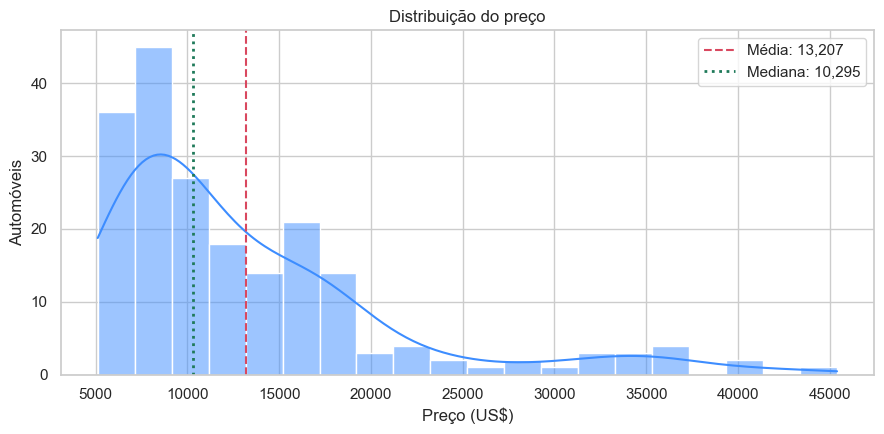

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(data=df, x="price", bins=20, kde=True, color=AZUL, ax=ax)
ax.axvline(media, color="#D9485F", linestyle="--", label=f"Média: {media:,.0f}")
ax.axvline(mediana, color="#1F7A5A", linestyle=":", linewidth=2, label=f"Mediana: {mediana:,.0f}")
ax.set(title="Distribuição do preço", xlabel="Preço (US$)", ylabel="Automóveis")
ax.legend()
plt.tight_layout()
plt.show()

### 3.1 Boxplot e possíveis outliers

In [ ]:
q1, q3 = df["price"].quantile([0.25, 0.75])
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
possiveis_outliers = df.loc[~df["price"].between(limite_inferior, limite_superior)]

print(f"Q1: {q1:,.0f} | Q3: {q3:,.0f} | IQR: {iqr:,.0f}")
print(f"Limite superior pelo critério 1,5 x IQR: {limite_superior:,.0f}")
print("Pontos sinalizados:", len(possiveis_outliers))

Q1: 7,775 | Q3: 16,500 | IQR: 8,725
Limite superior pelo critério 1,5 x IQR: 29,588
Pontos sinalizados: 14


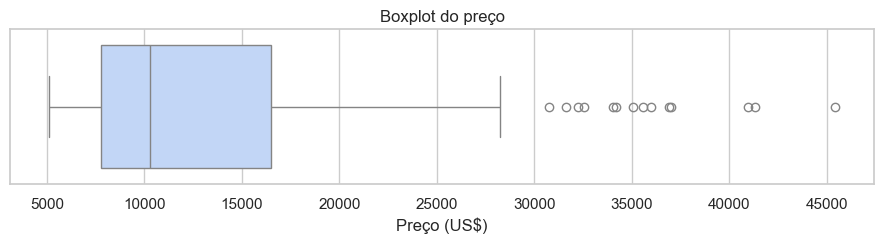

In [ ]:
fig, ax = plt.subplots(figsize=(9, 2.6))
sns.boxplot(data=df, x="price", color="#B9D4FF", ax=ax)
ax.set(title="Boxplot do preço", xlabel="Preço (US$)")
plt.tight_layout()
plt.show()

> **Outlier é um sinal para investigar, não uma ordem para excluir.** Um ponto distante pode ser erro, caso raro legítimo, fraude ou justamente a observação mais informativa. O critério do boxplot descreve distância; não conhece o contexto.

### 3.2 Categorias: contagem e proporção

In [ ]:
frequencia_carroceria = pd.DataFrame({
    "n": df["body-style"].value_counts(),
    "proporcao_%": df["body-style"].value_counts(normalize=True).mul(100).round(1),
})
frequencia_carroceria

,n,proporcao_%
body-style,,
sedan,94,46.80
hatchback,68,33.80
wagon,25,12.40
hardtop,8,4.00
convertible,6,3.00


## 4. `groupby()`: compare uma medida entre grupos

In [ ]:
preco_por_carroceria = (
    df.groupby("body-style", observed=True)["price"]
      .agg(n="count", media="mean", mediana="median", desvio_padrao="std")
      .sort_values("media", ascending=False)
)
preco_por_carroceria

,n,media,mediana,desvio_padrao
body-style,,,,
hardtop,8,"22,208.50","19,687.50","14,555.52"
convertible,6,"21,890.50","17,084.50","11,187.80"
sedan,94,"14,459.76","11,078.50","8,523.21"
wagon,25,"12,371.96","11,694.00","5,120.95"
hatchback,68,"9,957.44","8,672.00","4,148.86"


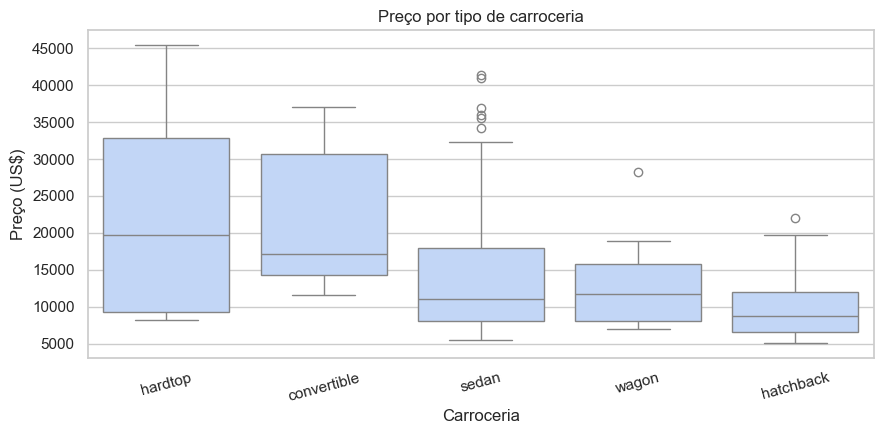

In [ ]:
ordem = preco_por_carroceria.index
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=df, x="body-style", y="price", order=ordem, color="#B9D4FF", ax=ax)
ax.set(title="Preço por tipo de carroceria", xlabel="Carroceria", ylabel="Preço (US$)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<div style="border-left: 4px solid #3D8DFF; padding: 8px 12px; background: #F6F9FF">
<strong>Pare e interprete:</strong> o grupo de maior média também possui muitos casos? Compare média, mediana, dispersão e <code>n</code> antes de afirmar que uma categoria “é mais cara”.
</div>

## 5. Laboratório - investigue e argumente

Responda às sete perguntas. Não entregue apenas saídas: para cada conclusão, registre **afirmação, evidência, interpretação e limitação**.

1. Como o preço está distribuído?
2. Quantos pontos são sinalizados como possíveis outliers pelo critério de 1,5 x IQR?
3. Qual tipo de carroceria tem maior preço médio? O tamanho do grupo sustenta uma afirmação forte?
4. Potência e preço parecem relacionados? Em que direção e com que intensidade?
5. Qual variável numérica possui maior correlação absoluta com `price` entre as variáveis originais selecionadas?
6. Crie um gráfico que sustente uma conclusão e escreva uma legenda interpretativa.
7. Escreva duas conclusões e ao menos uma limitação geral da análise.

### 1 e 2 - Distribuição e possíveis outliers

In [ ]:
# TODO: calcule média, mediana, assimetria, Q1, Q3, IQR e limites.
# Depois conte os pontos sinalizados e crie histograma + boxplot.
resposta_distribuicao = None

### 3 - Preço por carroceria

In [ ]:
# TODO: use groupby() e agregue n, média, mediana e desvio-padrão.
# Ordene pela média e compare a estabilidade dos grupos.
resposta_grupos = None

### 4. Insights e limitações

**Insight 1:** substitua por uma afirmação verificável.  
**Evidência:** informe número, tabela ou padrão visual.  
**Interpretação:** explique o que o resultado pode significar.  
**Limitação:** registre o que não pode ser concluído.

**Insight 2:** substitua por uma afirmação verificável.  
**Evidência:** informe número, tabela ou padrão visual.  
**Interpretação:** explique o que o resultado pode significar.  
**Limitação:** registre o que não pode ser concluído.

In [ ]:
# TODO: organize um DataFrame-resumo e exporte suas evidências.
# resumo_eda.to_csv("resumo_eda_entrega.csv", index=False)
# resposta_grupos.to_csv("preco_por_carroceria_entrega.csv")

## Checklist da entrega

- [ ] formulei perguntas antes de escolher gráficos;
- [ ] descrevi a distribuição de `price` com números e visualização;
- [ ] tratei pontos extremos como sinais para investigação;
- [ ] comparei grupos mostrando também o tamanho `n`.


## Fechamento

> **EDA não termina no gráfico.** Ela termina quando uma pergunta recebe uma resposta provisória, sustentada por evidência e delimitada por uma limitação.

## Fontes e licença

- Schlimmer, J. (1985). **Automobile** [Dataset]. UCI Machine Learning Repository. DOI: [10.24432/C5B01C](https://doi.org/10.24432/C5B01C). Licença CC BY 4.0.
- IBM Data Science Professional Certificate, curso **Data Analysis with Python**, Module 3 - Exploratory Data Analysis: [Coursera](https://www.coursera.org/learn/data-analysis-with-python).
- Pandas: [`describe`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html), [`groupby`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html), [`corr`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) e [`crosstab`](https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html).
- Seaborn: [`histplot`](https://seaborn.pydata.org/generated/seaborn.histplot.html), [`boxplot`](https://seaborn.pydata.org/generated/seaborn.boxplot.html), [`scatterplot`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) e [`heatmap`](https://seaborn.pydata.org/generated/seaborn.heatmap.html).
- SciPy: [`pearsonr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html) e [`chi2_contingency`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.chi2_contingency.html).